In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail.xlsx


###Task 1 – Data Import & Setup
● Load dataset using Pandas
● Explore structure: head(), tail(), shape, columns
● Convert InvoiceDate to datetime

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel("Online Retail.xlsx")

print("First 5 rows:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("\nData Types:")
print(df.dtypes)

First 5 rows:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  

Last 5 rows:
       InvoiceNo StockCode                      Description  Quantity  \
541904    581587     22613      PACK OF 20 SPACEBOY NAPKINS        12   
541905    58158

####Task 2 – Data Cleaning
● Handle missing values (remove null CustomerID)
● Remove duplicates
● Fix invalid values (negative quantity, invalid price)

In [ ]:
print("Missing values before cleaning:")
print(df.isnull().sum())

df = df.dropna(subset=["CustomerID"])

df = df.drop_duplicates()

df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

df = df.reset_index(drop=True)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nShape after cleaning:")
print(df.shape)

Missing values before cleaning:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Missing values after cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Shape after cleaning:
(392692, 8)


####Task 3 – Feature Engineering
● Create TotalPrice = Quantity × UnitPrice
● Extract time features (Year, Month, Day, Hour)
● Create categories (Customer Segment, Order Size, Day Type)

In [ ]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day
df["Hour"] = df["InvoiceDate"].dt.hour

customer_total = df.groupby("CustomerID")["TotalPrice"].sum()

def customer_segment(customer_id):
    total = customer_total[customer_id]

    if total < 500:
        return "Low Value"
    elif total < 2000:
        return "Medium Value"
    else:
        return "High Value"

df["Customer Segment"] = df["CustomerID"].apply(customer_segment)

def order_size(quantity):
    if quantity <= 5:
        return "Small"
    elif quantity <= 20:
        return "Medium"
    else:
        return "Large"

df["Order Size"] = df["Quantity"].apply(order_size)

df["Day Type"] = df["InvoiceDate"].dt.dayofweek.apply(lambda x: "Weekend" if x >= 5 else "Weekday")

print(df[[
    "InvoiceNo",
    "CustomerID",
    "Quantity",
    "UnitPrice",
    "TotalPrice",
    "Year",
    "Month",
    "Day",
    "Hour",
    "Customer Segment",
    "Order Size",
    "Day Type"]].head())

  InvoiceNo  CustomerID  Quantity  UnitPrice  TotalPrice  Year  Month  Day  \
0    536365     17850.0         6       2.55       15.30  2010     12    1   
1    536365     17850.0         6       3.39       20.34  2010     12    1   
2    536365     17850.0         8       2.75       22.00  2010     12    1   
3    536365     17850.0         6       3.39       20.34  2010     12    1   
4    536365     17850.0         6       3.39       20.34  2010     12    1   

   Hour Customer Segment Order Size Day Type  
0     8       High Value     Medium  Weekday  
1     8       High Value     Medium  Weekday  
2     8       High Value     Medium  Weekday  
3     8       High Value     Medium  Weekday  
4     8       High Value     Medium  Weekday  


###Task 4 – Data Exploration
● Use describe() and dataset overview
● Analyze categories (value_counts(), unique())
● Perform groupby() (country, month, product)

In [ ]:
print("Dataset Overview:")
print(df.info())

print("\nDescriptive Statistics:")
print(df.describe())

print("\nCountry Value Counts:")
print(df["Country"].value_counts())

print("\nUnique Countries:")
print(df["Country"].unique())

print("\nCustomer Segments:")
print(df["Customer Segment"].value_counts())

print("\nOrder Sizes:")
print(df["Order Size"].value_counts())

print("\nDay Types:")
print(df["Day Type"].value_counts())

print("\nSales by Country:")
country_sales = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False)
print(country_sales)

print("\nSales by Month:")
monthly_sales = df.groupby("Month")["TotalPrice"].sum()
print(monthly_sales)

print("\nTop 10 Products by Sales:")
product_sales = df.groupby("Description")["TotalPrice"].sum().sort_values(ascending=False)
print(product_sales.head(10))

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   InvoiceNo         392692 non-null  object        
 1   StockCode         392692 non-null  object        
 2   Description       392692 non-null  object        
 3   Quantity          392692 non-null  int64         
 4   InvoiceDate       392692 non-null  datetime64[ns]
 5   UnitPrice         392692 non-null  float64       
 6   CustomerID        392692 non-null  float64       
 7   Country           392692 non-null  object        
 8   TotalPrice        392692 non-null  float64       
 9   Year              392692 non-null  int32         
 10  Month             392692 non-null  int32         
 11  Day               392692 non-null  int32         
 12  Hour              392692 non-null  int32         
 13  Customer Segment  392692 non-null  object

####Task 5 – Data Wrangling
● Aggregate data using groupby()
● Sort to find the top customers and countries
● Restructure data if needed

In [ ]:
customer_sales = df.groupby("CustomerID").agg(Total_Spending=("TotalPrice", "sum"),Total_Quantity=("Quantity", "sum"),Number_of_Orders=("InvoiceNo", "nunique"))
top_customers = customer_sales.sort_values(by="Total_Spending",ascending=False).head(10)
print("Top 10 Customers:")
print(top_customers)

country_sales = df.groupby("Country").agg(Total_Sales=("TotalPrice", "sum"),Total_Quantity=("Quantity", "sum"),Number_of_Orders=("InvoiceNo", "nunique"))

top_countries = country_sales.sort_values(by="Total_Sales",ascending=False).head(10)

print("\nTop 10 Countries:")
print(top_countries)

monthly_country_sales = pd.pivot_table( df,values="TotalPrice",index="Month",columns="Country",aggfunc="sum",fill_value=0)
print("\nMonthly Sales by Country:")
print(monthly_country_sales)

Top 10 Customers:
            Total_Spending  Total_Quantity  Number_of_Orders
CustomerID                                                  
14646.0          280206.02          196915                73
18102.0          259657.30           64124                60
17450.0          194390.79           69973                46
16446.0          168472.50           80997                 2
14911.0          143711.17           80240               201
12415.0          124914.53           77374                21
14156.0          117210.08           57768                55
17511.0           91062.38           64549                31
16029.0           80850.84           40108                63
12346.0           77183.60           74215                 1

Top 10 Countries:
                Total_Sales  Total_Quantity  Number_of_Orders
Country                                                      
United Kingdom  7285024.644         4241305             16646
Netherlands      285446.340          200361  

####Task 6 – Statistical Analysis
● Analyze Quantity, UnitPrice, TotalPrice
● Calculate mean, median, and mode
● Find standard deviation, variance, and percentiles

In [ ]:
columns = ["Quantity", "UnitPrice", "TotalPrice"]

for column in columns:
    print("\n", column)
    print("Mean:", df[column].mean())
    print("Median:", df[column].median())
    print("Mode:", df[column].mode()[0])
    print("Standard Deviation:", df[column].std())
    print("Variance:", df[column].var())
    print("25th Percentile:", df[column].quantile(0.25))
    print("50th Percentile:", df[column].quantile(0.50))
    print("75th Percentile:", df[column].quantile(0.75))
    print("90th Percentile:", df[column].quantile(0.90))
    print("95th Percentile:", df[column].quantile(0.95))


 Quantity
Mean: 13.1197019547126
Median: 6.0
Mode: 1
Standard Deviation: 180.49283198920438
Variance: 32577.662399483157
25th Percentile: 2.0
50th Percentile: 6.0
75th Percentile: 12.0
90th Percentile: 24.0
95th Percentile: 36.0

 UnitPrice
Mean: 3.125913907082396
Median: 1.95
Mode: 1.25
Standard Deviation: 22.241835614059994
Variance: 494.69925148286745
25th Percentile: 1.25
50th Percentile: 1.95
75th Percentile: 3.75
90th Percentile: 6.35
95th Percentile: 8.5

 TotalPrice
Mean: 22.6314997351614
Median: 12.45
Mode: 15.0
Standard Deviation: 311.09922433483325
Variance: 96782.72738173489
25th Percentile: 4.949999999999999
50th Percentile: 12.45
75th Percentile: 19.799999999999997
90th Percentile: 35.400000000000006
95th Percentile: 67.5


####Task 7 – Data Visualization — Matplotlib
1. Line Chart — Monthly Sales

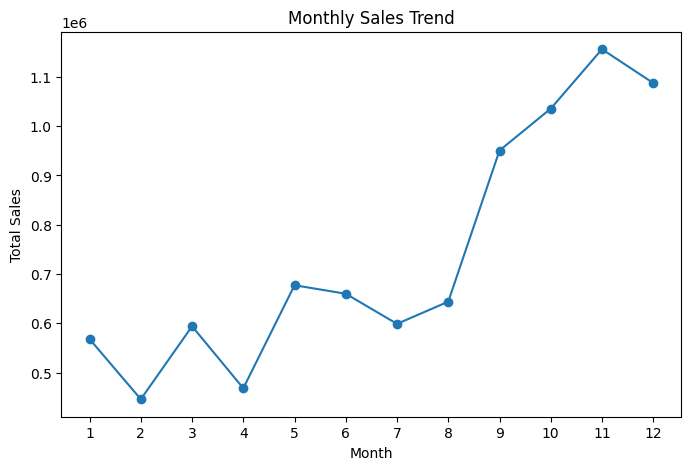

In [ ]:
monthly_sales = df.groupby("Month")["TotalPrice"].sum()

plt.figure(figsize=(8,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend")
plt.xticks(range(1, 13))
plt.show()

Sales fluctuate across the months, with noticeable peaks and declines indicating seasonal variations in customer purchasing.

###2. Bar Chart — Top 10 Countries

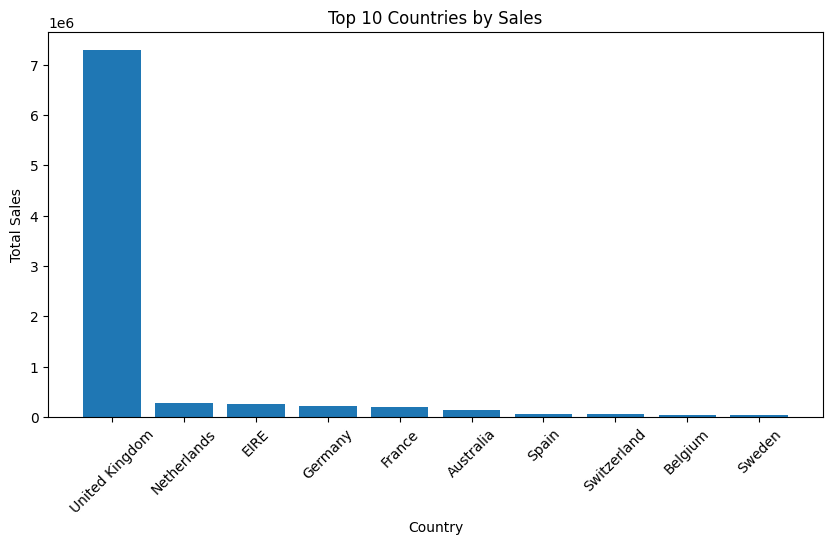

In [ ]:
country_sales = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(country_sales.index, country_sales.values)

plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.title("Top 10 Countries by Sales")
plt.xticks(rotation=45)
plt.show()

The United Kingdom generates the highest sales, while the remaining countries contribute comparatively smaller amounts.

###3. Histogram — Quantity

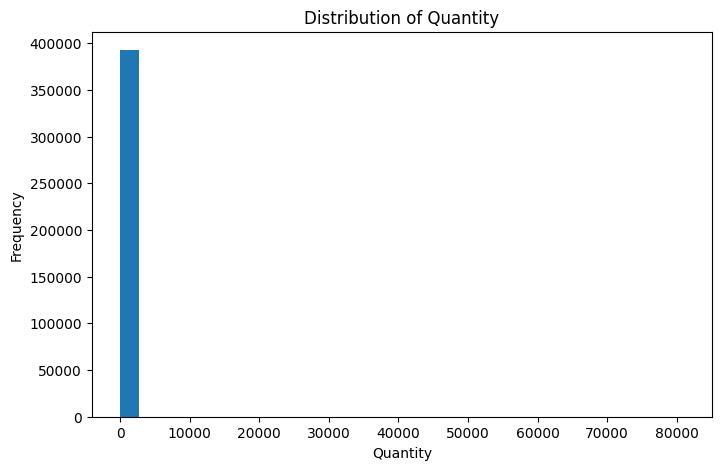

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df["Quantity"], bins=30)

plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.title("Distribution of Quantity")
plt.show()

Quantity is highly right-skewed, with most transactions involving small quantities and a few transactions having very large quantities.

####4. Box Plot — Unit Price

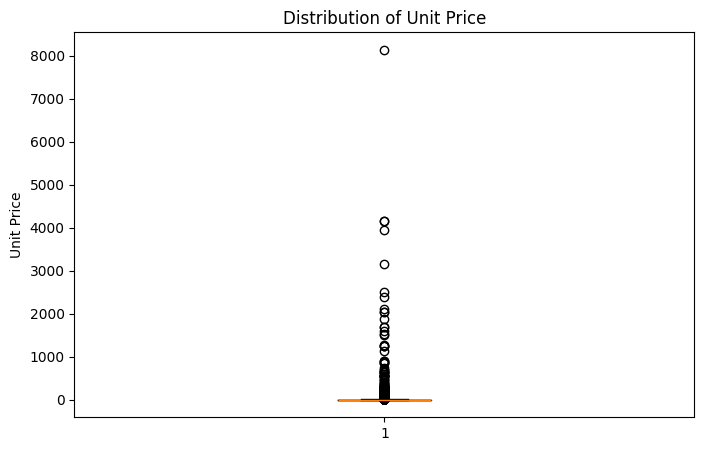

In [ ]:
plt.figure(figsize=(8,5))
plt.boxplot(df["UnitPrice"])

plt.ylabel("Unit Price")
plt.title("Distribution of Unit Price")
plt.show()

Unit prices are concentrated at lower values, with a long right tail caused by a small number of high-priced products.

####Task 7 – Data Visualization — Seaborn
5. Count Plot — Orders by Day Type

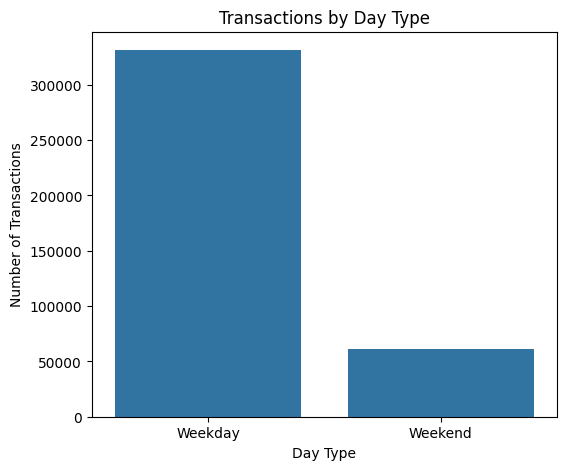

In [ ]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x="Day Type")

plt.xlabel("Day Type")
plt.ylabel("Number of Transactions")
plt.title("Transactions by Day Type")
plt.show()

The number of transactions differs between weekdays and weekends, showing that purchasing activity is influenced by the day type.

####6. Violin Plot — Total Price by Customer Segment

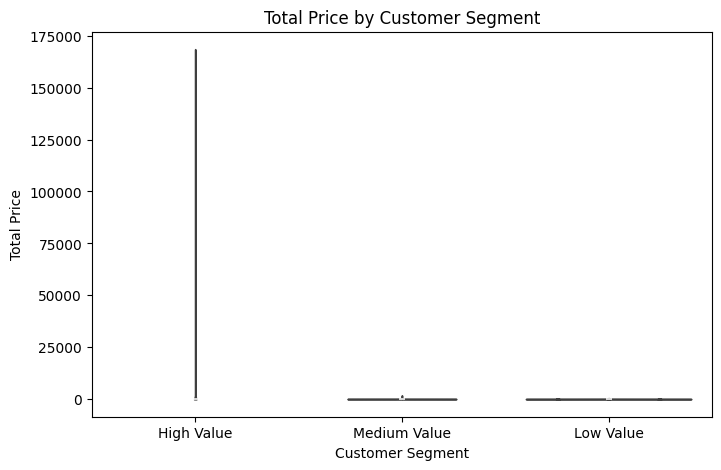

In [ ]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df, x="Customer Segment", y="TotalPrice")

plt.xlabel("Customer Segment")
plt.ylabel("Total Price")
plt.title("Total Price by Customer Segment")
plt.show()

Customer segments show different spending distributions, with some segments exhibiting higher transaction values and greater variability.

####7. Heatmap — Correlation

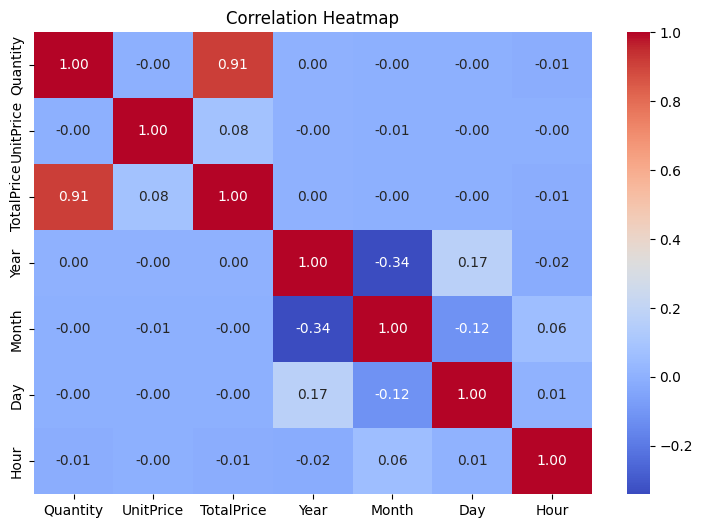

In [ ]:
correlation = df[[
    "Quantity",
    "UnitPrice",
    "TotalPrice",
    "Year",
    "Month",
    "Day",
    "Hour"
]].corr()

plt.figure(figsize=(9,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

Total Price has a strong positive relationship with Quantity and Unit Price, while the time-based variables show relatively weaker relationships with sales.

####8. Pair Plot — Numerical Variables

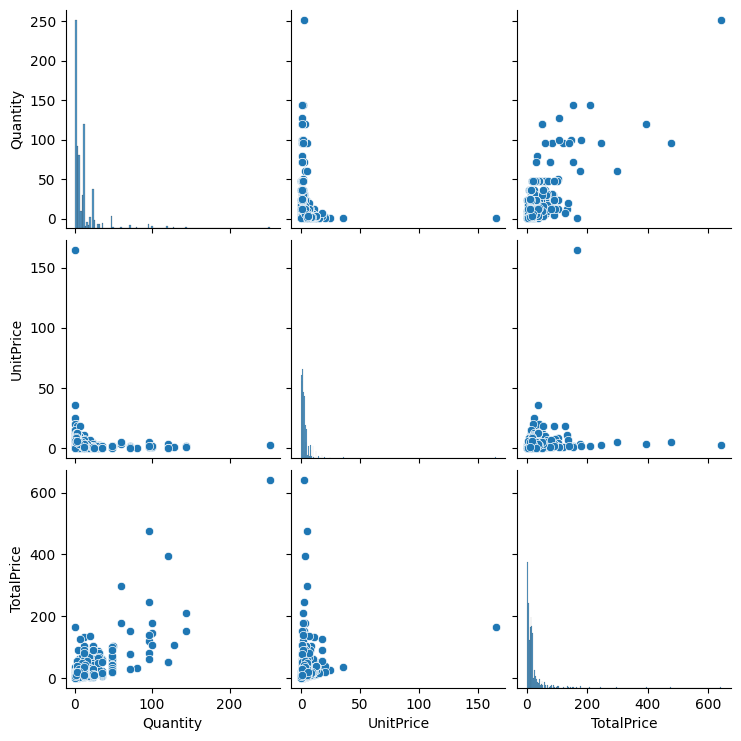

In [ ]:
sample_df = df[[
    "Quantity",
    "UnitPrice",
    "TotalPrice"
]].sample(1000, random_state=42)

sns.pairplot(sample_df)

plt.show()

The pair plot shows that Total Price increases strongly with Quantity, while the relationship between Unit Price and Quantity is relatively weak.

####Task 8 – Business Insights ● Identify: ○ Top country ○ Best sales month ○ Peak sales time ● Analyze: ○ Customer behavior ○ High-value customers ○ Top products

###1. Identify Top Country

In [ ]:
top_country = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False)

print("Top 10 Countries by Sales:")
print(top_country.head(10))

print("\nTop Country:")
print(top_country.index[0])
print("Total Sales:", top_country.iloc[0])

Top 10 Countries by Sales:
Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalPrice, dtype: float64

Top Country:
United Kingdom
Total Sales: 7285024.644


###2. Identify Best Sales Month

In [ ]:
monthly_sales = df.groupby("Month")["TotalPrice"].sum().sort_values(ascending=False)

print("Sales by Month:")
print(monthly_sales)

print("\nBest Sales Month:")
print(monthly_sales.index[0])
print("Total Sales:", monthly_sales.iloc[0])

Sales by Month:
Month
11    1156205.610
12    1087613.170
10    1035642.450
9      950690.202
5      677355.150
6      660046.050
8      644051.040
7      598962.901
3      594081.760
1      568101.310
4      468374.331
2      446084.920
Name: TotalPrice, dtype: float64

Best Sales Month:
11
Total Sales: 1156205.61


####3. Identify Peak Sales Time

In [ ]:
hourly_sales = df.groupby("Hour")["TotalPrice"].sum().sort_values(ascending=False)

print("Sales by Hour:")
print(hourly_sales)

print("\nPeak Sales Hour:")
print(hourly_sales.index[0])
print("Total Sales:", hourly_sales.iloc[0])

Sales by Hour:
Hour
12    1373695.390
10    1259267.591
13    1168724.200
11    1101177.600
14     991992.821
15     963559.680
9      842392.341
16     467380.560
8      281997.790
17     233811.591
18     104744.990
19      48568.400
7       31059.210
20      18832.480
6           4.250
Name: TotalPrice, dtype: float64

Peak Sales Hour:
12
Total Sales: 1373695.39


###4. Analyze Customer Behavior

In [ ]:
customer_behavior = df.groupby("CustomerID").agg(Total_Spending=("TotalPrice", "sum"),Total_Quantity=("Quantity", "sum"),Number_of_Orders=("InvoiceNo", "nunique"))

customer_behavior = customer_behavior.sort_values(by="Total_Spending",ascending=False)
print("Top 10 Customers by Spending:")
print(customer_behavior.head(10))

Top 10 Customers by Spending:
            Total_Spending  Total_Quantity  Number_of_Orders
CustomerID                                                  
14646.0          280206.02          196915                73
18102.0          259657.30           64124                60
17450.0          194390.79           69973                46
16446.0          168472.50           80997                 2
14911.0          143711.17           80240               201
12415.0          124914.53           77374                21
14156.0          117210.08           57768                55
17511.0           91062.38           64549                31
16029.0           80850.84           40108                63
12346.0           77183.60           74215                 1


##5. Analyze High-Value Customers

In [ ]:
high_value_customers = customer_behavior[
    customer_behavior["Total_Spending"] >= 2000]

print("High-Value Customers:")
print(high_value_customers.head(10))

High-Value Customers:
            Total_Spending  Total_Quantity  Number_of_Orders
CustomerID                                                  
14646.0          280206.02          196915                73
18102.0          259657.30           64124                60
17450.0          194390.79           69973                46
16446.0          168472.50           80997                 2
14911.0          143711.17           80240               201
12415.0          124914.53           77374                21
14156.0          117210.08           57768                55
17511.0           91062.38           64549                31
16029.0           80850.84           40108                63
12346.0           77183.60           74215                 1


##6. Analyze Top Products

In [ ]:
top_products = df.groupby("Description").agg(
    Total_Sales=("TotalPrice", "sum"),
    Total_Quantity=("Quantity", "sum"))

top_products = top_products.sort_values(by="Total_Sales",ascending=False)
print("Top 10 Products:")
print(top_products.head(10))

Top 10 Products:
                                    Total_Sales  Total_Quantity
Description                                                    
PAPER CRAFT , LITTLE BIRDIE           168469.60           80995
REGENCY CAKESTAND 3 TIER              142264.75           12374
WHITE HANGING HEART T-LIGHT HOLDER    100392.10           36706
JUMBO BAG RED RETROSPOT                85040.54           46078
MEDIUM CERAMIC TOP STORAGE JAR         81416.73           77916
POSTAGE                                77803.96            3120
PARTY BUNTING                          68785.23           15279
ASSORTED COLOUR BIRD ORNAMENT          56413.03           35263
Manual                                 53419.93            6933
RABBIT NIGHT LIGHT                     51251.24           27153


##Task 8: Business Insights

1. Top Country:
   United Kingdom is the top-performing country and generates
   the highest total sales.

2. Best Sales Month:
   November is the best sales month, indicating strong customer
   purchasing activity during this period.

3. Peak Sales Time:
   The peak sales period is around 12 PM, showing that this is
   the busiest sales time.

4. Customer Behavior:
   Customer spending varies considerably. A smaller group of
   customers contributes a significant portion of the total
   revenue, while many customers make smaller purchases.

5. High-Value Customers:
   Customers with high total spending and frequent orders are
   the most valuable customers. These customers should be
   targeted with loyalty programs and special offers.

6. Top Products:
   A small number of products generate a large amount of sales.
   These products should be properly stocked to avoid
   stock shortages.

7. Business Recommendation:
   The business should focus on retaining high-value customers,
   maintaining sufficient stock of top-selling products, and
   running promotions during high-sales months and peak
   purchasing hours.